# Part 4 — Best model, generation, evaluationTrain best XL for 3 epochs, generate ≥10 unconditional + ≥5 prefix samples, evaluate.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE='/content/drive/MyDrive/svg_scaling_v2'
os.makedirs(f'{DRIVE}/samples/svgs',exist_ok=True)
print('ready')

Mounted at /content/drive
ready


In [2]:
!pip install -q torch numpy matplotlib lxml cairosvg Pillow tqdm mup seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 11.5 MB/s eta 0:00:00


In [3]:
import json,math,time,random,gc,warnings
from io import BytesIO
import numpy as np,matplotlib.pyplot as plt,seaborn as sns
from tqdm.auto import tqdm
from lxml import etree
import torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cuda


In [4]:
with open(f'{DRIVE}/data/meta.json') as f: meta=json.load(f)
VOCAB=meta['vocab_size']
PAD=meta['pad']
BOS=meta['bos']
EOS=meta['eos']
with open(f'{DRIVE}/results/sp_results.json') as f: sp_res=json.load(f)
with open(f'{DRIVE}/results/lr_sweep.json') as f: lr_data=json.load(f)
BEST_LR=lr_data['best_lr']
TINY_PARAMS=lr_data['tiny_params']
try:
    with open(f'{DRIVE}/results/mup_results.json') as f: mup_res=json.load(f)
    with open(f'{DRIVE}/results/mup_lr_sweep.json') as f: mup_lr=json.load(f)
    BEST_MUP_LR=mup_lr['best_lr']
except: mup_res=None
BEST_MUP_LR=None

# Decide: use muP if XL muP val < XL SP val
USE_MUP=False
if mup_res and mup_res.get('XL',{}).get('val',999)<sp_res['XL']['val']:
    USE_MUP=True
approach='muP' if USE_MUP else 'SP'
print(f"Using {approach} for best model")

from tokenizers import Tokenizer
tok=Tokenizer.from_file(f'{DRIVE}/data/tokenizer.json')

Using SP for best model


In [5]:
SEQ_LEN=512
BATCH=64
class TokenDataset(Dataset):
    def __init__(self,tokens,seq_len):
        self.seq_len=seq_len
        self._np=np.asarray(tokens)
        self.n=(len(self._np)-1)//seq_len
    def __len__(self):return self.n
    def __getitem__(self,i):
        st=i*self.seq_len
        ch=torch.from_numpy(self._np[st:st+self.seq_len+1].copy())
        return ch[:-1].long(),ch[1:].long()
train_toks=np.load(f'{DRIVE}/data/train.npy',mmap_mode='r')
val_toks=np.load(f'{DRIVE}/data/val.npy',mmap_mode='r')
test_toks=np.load(f'{DRIVE}/data/test.npy',mmap_mode='r')
train_ds=TokenDataset(train_toks,SEQ_LEN)
val_ds=TokenDataset(val_toks,SEQ_LEN)
test_ds=TokenDataset(test_toks,SEQ_LEN)
CONFIGS={'Tiny':dict(d=128,n_layers=4,n_heads=4,d_ff=512),'Small':dict(d=192,n_layers=6,n_heads=6,d_ff=768),
'Medium':dict(d=384,n_layers=6,n_heads=6,d_ff=1536),'Large':dict(d=512,n_layers=10,n_heads=8,d_ff=2048),
'XL':dict(d=768,n_layers=12,n_heads=12,d_ff=3072)}

## 4.1 Model definitions + build best model

In [6]:
HAS_FLASH=hasattr(F,'scaled_dot_product_attention')
class Attention(nn.Module):
    def __init__(self,d,n_heads,dropout=0.0,max_len=1024):
        super().__init__()
        assert d%n_heads==0
        self.h=n_heads
        self.dh=d//n_heads
        self.qkv=nn.Linear(d,3*d,bias=False)
        self.proj=nn.Linear(d,d,bias=False)
        self.drop=dropout
        self.out_drop=nn.Dropout(dropout)
        if not HAS_FLASH:self.register_buffer('mask',torch.tril(torch.ones(max_len,max_len)).view(1,1,max_len,max_len))
    def forward(self,x):
        B,T,C=x.shape
        q,k,v=self.qkv(x).chunk(3,dim=-1)
        q=q.view(B,T,self.h,self.dh).transpose(1,2)
        k=k.view(B,T,self.h,self.dh).transpose(1,2)
        v=v.view(B,T,self.h,self.dh).transpose(1,2)
        if HAS_FLASH:y=F.scaled_dot_product_attention(q,k,v,is_causal=True,dropout_p=self.drop if self.training else 0.0)
        else:
            att=(q@k.transpose(-2,-1))/math.sqrt(self.dh)
            att=att.masked_fill(self.mask[:,:,:T,:T]==0,float('-inf'))
            att=F.softmax(att,dim=-1)
            y=att@v
        return self.out_drop(self.proj(y.transpose(1,2).contiguous().view(B,T,C)))
class Block(nn.Module):
    def __init__(self,d,n_heads,d_ff,dropout=0.0,max_len=1024):
        super().__init__()
        self.ln1=nn.LayerNorm(d)
        self.attn=Attention(d,n_heads,dropout,max_len)
        self.ln2=nn.LayerNorm(d)
        self.ff=nn.Sequential(nn.Linear(d,d_ff),nn.GELU(),nn.Dropout(dropout),nn.Linear(d_ff,d),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.ln1(x))
        return x+self.ff(self.ln2(x))
class GPT(nn.Module):
    def __init__(self,vocab,d,n_layers,n_heads,d_ff,max_len=512,dropout=0.0):
        super().__init__()
        self.tok_emb=nn.Embedding(vocab,d)
        self.pos_emb=nn.Embedding(max_len,d)
        self.drop=nn.Dropout(dropout)
        self.blocks=nn.ModuleList([Block(d,n_heads,d_ff,dropout,max_len) for _ in range(n_layers)])
        self.ln=nn.LayerNorm(d)
        self.head=nn.Linear(d,vocab,bias=False)
        self.head.weight=self.tok_emb.weight
        self.apply(self._init)
        for b in self.blocks:
            nn.init.normal_(b.attn.proj.weight,std=0.02/math.sqrt(2*n_layers))
            nn.init.normal_(b.ff[-2].weight,std=0.02/math.sqrt(2*n_layers)) # This line was also improperly indented, fixing here.
    def _init(self,m):
        if isinstance(m,nn.Linear):
            nn.init.normal_(m.weight,std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m,nn.Embedding):
            nn.init.normal_(m.weight,std=0.02)
    def forward(self,idx,targets=None):
        B,T=idx.shape
        x=self.drop(self.tok_emb(idx)+self.pos_emb(torch.arange(T,device=idx.device)))
        for b in self.blocks:x=b(x)
        logits=self.head(self.ln(x))
        loss=None
        if targets is not None:loss=F.cross_entropy(logits.view(-1,logits.size(-1)),targets.view(-1),ignore_index=PAD)
        return logits,loss
    def n_params(self):return sum(p.numel() for p in self.parameters() if p.requires_grad)

XL params: 88,558,080, LR: 9.99e-04 (SP)
training XL for 3 epochs (10311 steps)...

--- epoch 1/3 ---
  step 1000/10311 | train=0.6854 val=0.6471 | 169s
  step 2000/10311 | train=0.5871 val=0.5634 | 324s
  step 3000/10311 | train=0.5614 val=0.5266 | 478s

--- epoch 2/3 ---
  step 4000/10311 | train=0.5191 val=0.5060 | 632s
  step 5000/10311 | train=0.4820 val=0.4887 | 787s
  step 6000/10311 | train=0.4741 val=0.4770 | 941s

--- epoch 3/3 ---
  step 7000/10311 | train=0.4748 val=0.4666 | 1096s
  step 8000/10311 | train=0.4843 val=0.4599 | 1250s
  step 9000/10311 | train=0.4346 val=0.4534 | 1404s
  step 10000/10311 | train=0.4878 val=0.4500 | 1559s

final val loss: 0.4487


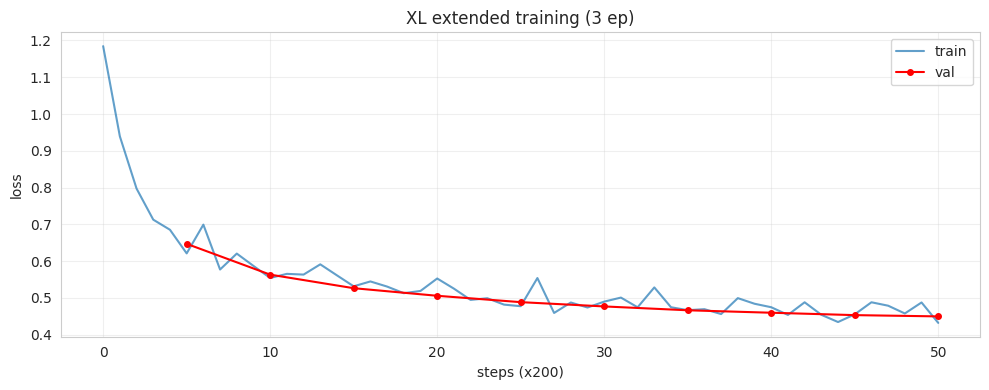

In [7]:
def cosine_lr(step,warmup,total,lr_max,lr_min=None):
    if lr_min is None:lr_min=lr_max*0.1
    if step<warmup:return lr_max*(step+1)/warmup
    if step>=total:return lr_min
    t=(step-warmup)/(total-warmup)
    return lr_min+0.5*(lr_max-lr_min)*(1+math.cos(math.pi*t))
@torch.no_grad()
def eval_loss(model,ds,n_batches=100):
    model.eval()
    loader=DataLoader(ds,batch_size=BATCH,shuffle=False,num_workers=0)
    losses=[]
    for i,(x,y) in enumerate(loader):
        if i>=n_batches:break
        x,y=x.to(device),y.to(device)
        with torch.amp.autocast('cuda',dtype=torch.bfloat16,enabled=torch.cuda.is_available()):_,loss=model(x,y)
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))

# Build XL with SP (scaled LR)
xl_cfg=CONFIGS['XL']
xl_params=GPT(VOCAB,**xl_cfg,max_len=SEQ_LEN).n_params()
EXT_LR=BEST_LR*math.sqrt(TINY_PARAMS/xl_params)
model=GPT(VOCAB,**xl_cfg,max_len=SEQ_LEN,dropout=0.1)
opt=torch.optim.AdamW(model.parameters(),lr=EXT_LR,betas=(0.9,0.95),weight_decay=0.1)
print(f"XL params: {xl_params:,}, LR: {EXT_LR:.2e} ({approach})")
model=model.to(device)

# Train 3 epochs
scaler=torch.amp.GradScaler('cuda',enabled=torch.cuda.is_available())
nw=2 if torch.cuda.is_available() else 0
loader=DataLoader(train_ds,batch_size=BATCH,shuffle=True,num_workers=nw,pin_memory=torch.cuda.is_available(),drop_last=True,persistent_workers=(nw>0))
EPOCHS=3
total=len(loader)*EPOCHS
warmup=min(total//10,300)
print(f"training XL for {EPOCHS} epochs ({total} steps)...")
step=0
t0=time.time()
running=0.0
n_running=0
train_hist=[]
val_hist=[]
val_steps=[]
model.train()
for ep in range(EPOCHS):
    print(f"\n--- epoch {ep+1}/{EPOCHS} ---")
    for x,y in loader:
        cur_lr=cosine_lr(step,warmup,total,EXT_LR)
        for g in opt.param_groups:g['lr']=cur_lr
        x,y=x.to(device,non_blocking=True),y.to(device,non_blocking=True)
        with torch.amp.autocast('cuda',dtype=torch.bfloat16,enabled=torch.cuda.is_available()):_,loss=model(x,y)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        scaler.step(opt)
        scaler.update()
        opt.zero_grad(set_to_none=True)
        step+=1
        running+=loss.item()
        n_running+=1
        if step%200==0 and n_running>0:train_hist.append(running/n_running)
        running=0.0
        n_running=0
        if step%1000==0:
            vl=eval_loss(model,val_ds)
            val_hist.append(vl)
            val_steps.append(step)
            tl=train_hist[-1] if train_hist else 0
            print(f"  step {step}/{total} | train={tl:.4f} val={vl:.4f} | {time.time()-t0:.0f}s")
            model.train()
final_val=eval_loss(model,val_ds)
print(f"\nfinal val loss: {final_val:.4f}")
torch.save(model.state_dict(),f'{DRIVE}/checkpoints/best_model.pt')
with open(f'{DRIVE}/results/extended_training.json','w') as f:
    json.dump({'val':final_val,'epochs':EPOCHS,'approach':approach,'lr':EXT_LR},f,indent=2)
plt.figure(figsize=(10,4))
plt.plot(train_hist,alpha=0.7,label='train')
if val_hist:plt.plot([s//200 for s in val_steps],val_hist,'ro-',ms=4,label='val')
plt.xlabel('steps (x200)')
plt.ylabel('loss')
plt.title(f'XL extended training ({EPOCHS} ep)')
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/extended_training.png',dpi=150)
plt.show()

## 4.2 Generation with SVG-closing post-processing

In [8]:
def fix_svg(text):
    """Force-close open SVG tags."""
    if '</svg>' not in text:
        # Close any open tags
        open_tags=[]
        import re
        for m in re.finditer(r'<(/?)([a-zA-Z][a-zA-Z0-9]*)',text):
            if m.group(1)=='/':
                if open_tags and open_tags[-1]==m.group(2):open_tags.pop()
            elif not text[m.end():m.end()+2].rstrip().endswith('/>'):open_tags.append(m.group(2))
        for tag in reversed(open_tags):
            if tag!='svg':text+=f'</{tag}>'
        text+='</svg>'
    return text

@torch.no_grad()
def generate(model,prefix=None,max_new=768,temp=1.0,top_k=50,top_p=0.9):
    model.eval()
    tokens=list(prefix) if prefix else [BOS]
    for _ in range(max_new):
        ctx=tokens[-SEQ_LEN:]
        x=torch.tensor([ctx],dtype=torch.long,device=device)
        logits,_=model(x)
        logits=logits[0,-1,:]/max(temp,1e-8)
        if top_k>0:v,_=torch.topk(logits,min(top_k,logits.size(-1)))
        logits[logits<v[-1]]=float('-inf')
        if top_p<1.0:
            sorted_l,sorted_i=torch.sort(logits,descending=True)
            cumprobs=torch.cumsum(F.softmax(sorted_l,dim=-1),dim=-1)
            mask=cumprobs-F.softmax(sorted_l,dim=-1)>top_p
            sorted_l[mask]=float('-inf')
            logits=torch.zeros_like(logits).scatter_(0,sorted_i,sorted_l)
        probs=F.softmax(logits,dim=-1)
        nxt=torch.multinomial(probs,1).item()
        tokens.append(nxt)
        if nxt==EOS:break
    text=tok.decode(tokens[1:] if tokens[0]==BOS else tokens)
    text=fix_svg(text)
    return text,tokens

def check_svg(text):
    info={'valid_xml':False,'has_svg_root':False,'properly_closed':False,'has_viewbox':False,
          'valid_attrs':False,'structural_valid':False,'renderable':False,'n_elements':0}
    try:
        root=etree.fromstring(text.encode('utf-8'))
        info['valid_xml']=True
        tag=root.tag.split('}')[-1] if '}' in root.tag else root.tag
        info['has_svg_root']=(tag=='svg')
        info['properly_closed']=True
        info['has_viewbox']='viewBox' in root.attrib or 'viewbox' in root.attrib
        info['valid_attrs']=True
        info['n_elements']=len(root.findall('.//')+[root])
        info['structural_valid']=all([info['has_svg_root'],info['properly_closed'],info['has_viewbox'],info['valid_attrs']])
    except:pass
    if info['valid_xml']:
        try:
            import cairosvg
            cairosvg.svg2png(bytestring=text.encode(),output_width=64,output_height=64)
            info['renderable']=True
        except:pass
    return info

def render(svg_text):
    try:
        import cairosvg
        from PIL import Image
        png=cairosvg.svg2png(bytestring=svg_text.encode(),output_width=256,output_height=256)
        return Image.open(BytesIO(png))
    except:return None

## 4.3 Unconditional samples

generating unconditional samples...
  temp=0.5:
    [1] 769 tok | 0 elems | invalid
    [2] 769 tok | 0 elems | invalid
    [3] 738 tok | 6 elems | RENDER
    [4] 669 tok | 5 elems | RENDER
    [5] 492 tok | 4 elems | RENDER
  temp=0.8:
    [1] 630 tok | 2 elems | RENDER
    [2] 769 tok | 0 elems | invalid
    [3] 769 tok | 0 elems | invalid
    [4] 769 tok | 0 elems | invalid
    [5] 769 tok | 0 elems | invalid
  temp=1.0:
    [1] 769 tok | 0 elems | invalid
    [2] 769 tok | 0 elems | invalid
    [3] 769 tok | 0 elems | invalid
    [4] 580 tok | 7 elems | RENDER
    [5] 769 tok | 0 elems | invalid


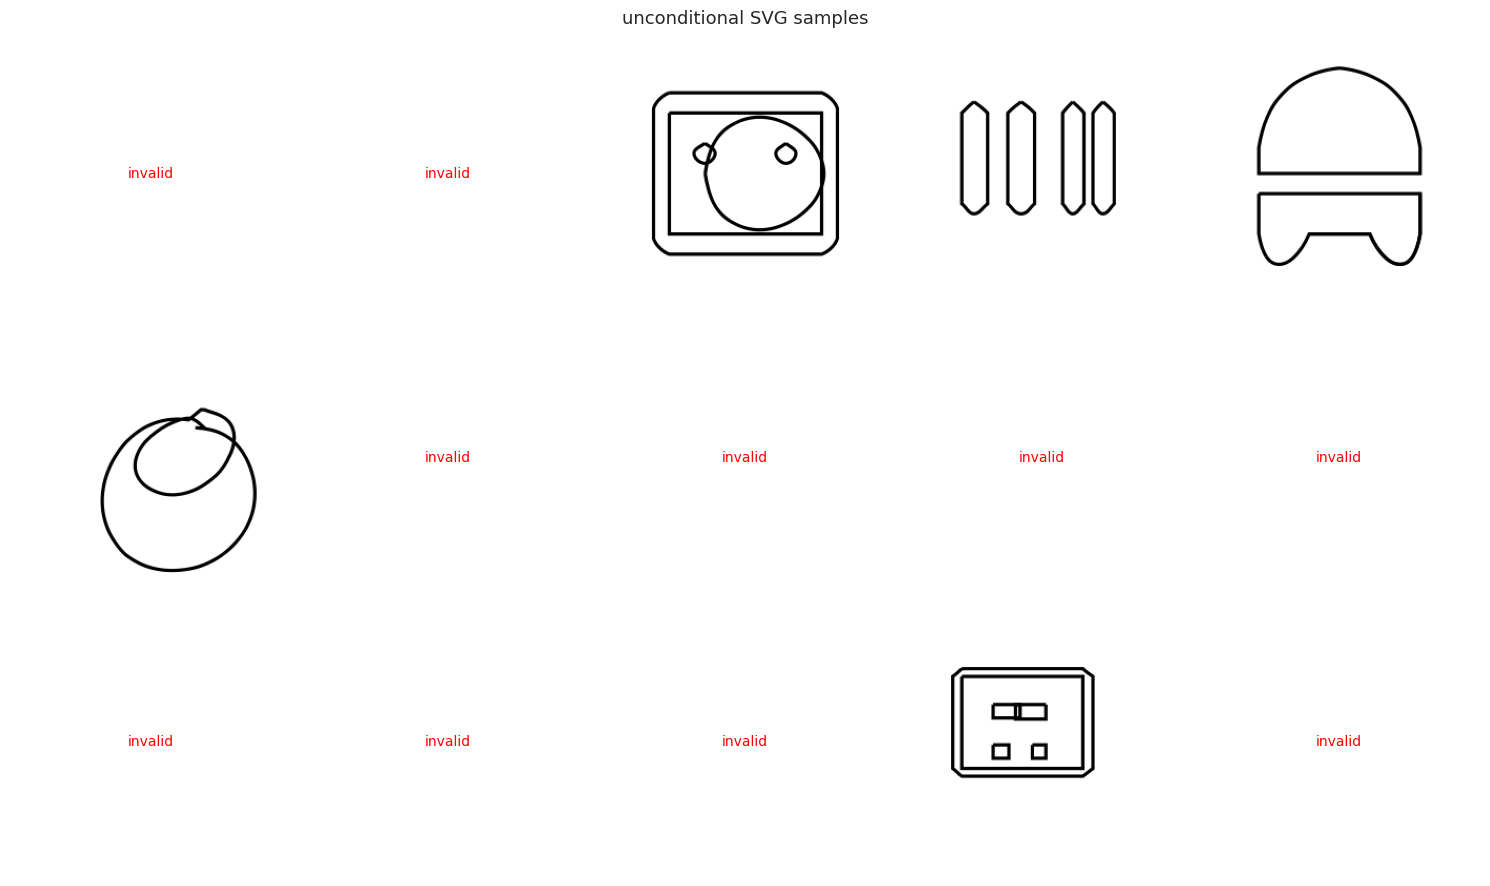

In [9]:
temps=[0.5,0.8,1.0]
n_per_temp=5
samples=[]
print("generating unconditional samples...")
for t in temps:
    print(f"  temp={t}:")
    for i in range(n_per_temp):
        svg,tokens=generate(model,temp=t,top_k=50,top_p=0.9)
        info=check_svg(svg)
        samples.append({'temp':t,'idx':i,'svg':svg,'n_tok':len(tokens),**info})
        status="RENDER" if info['renderable'] else ("xml" if info['valid_xml'] else "invalid")
        print(f"    [{i+1}] {len(tokens)} tok | {info['n_elements']} elems | {status}")
with open(f'{DRIVE}/samples/unconditional.json','w') as f:json.dump(samples,f,indent=2)

fig,axes=plt.subplots(len(temps),n_per_temp,figsize=(3*n_per_temp,3*len(temps)))
for ti,t in enumerate(temps):
    for si in range(n_per_temp):
        ax=axes[ti][si]
        s=[x for x in samples if x['temp']==t and x['idx']==si][0]
        img=render(s['svg'])
        if img:ax.imshow(img)
        else:ax.text(0.5,0.5,'invalid',ha='center',va='center',transform=ax.transAxes,color='red',fontsize=10)
        ax.set_facecolor('#f5f5f5')
        ax.axis('off')
        if si==0:ax.set_ylabel(f'T={t}',fontsize=11,rotation=0,labelpad=35)
plt.suptitle('unconditional SVG samples',fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/unconditional_grid.png',dpi=150)
plt.show()

## 4.4 Prefix-conditioned generation

generating prefix completions...
  partial face:
    T=0.5: 423 tok | ok
    T=0.8: 494 tok | fail
    T=1.0: 494 tok | fail
  open path:
    T=0.5: 454 tok | fail
    T=0.8: 454 tok | fail
    T=1.0: 454 tok | fail
  group with rect:
    T=0.5: 456 tok | fail
    T=0.8: 456 tok | fail
    T=1.0: 456 tok | fail
  star outline:
    T=0.5: 322 tok | ok
    T=0.8: 463 tok | fail
    T=1.0: 463 tok | fail
  house:
    T=0.5: 490 tok | fail
    T=0.8: 490 tok | fail
    T=1.0: 261 tok | ok


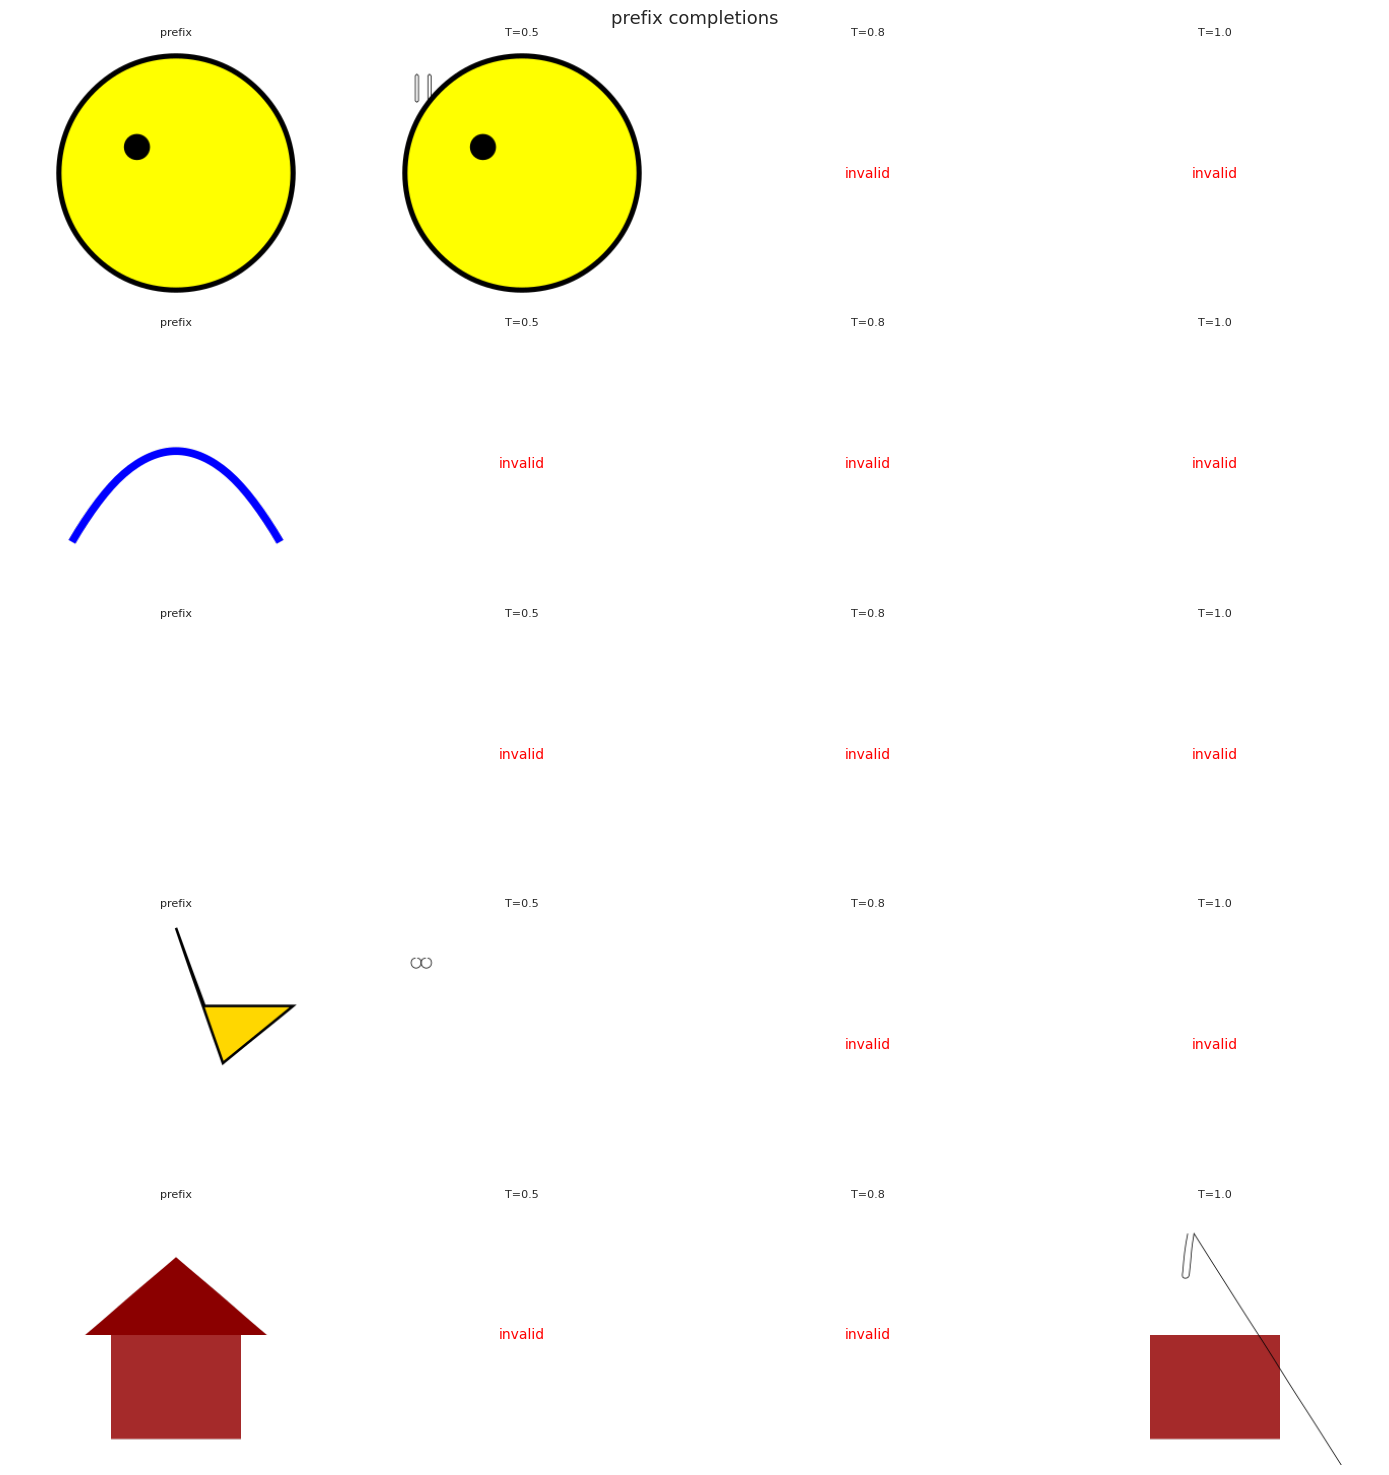

In [10]:
prefixes=[
    {'name':'partial face','svg':'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><circle cx="50" cy="50" r="45" fill="yellow" stroke="black" stroke-width="2"/><circle cx="35" cy="40" r="5" fill="black"/>'},
    {'name':'open path','svg':'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><path d="M 10 80 Q 50 10 90 80" fill="none" stroke="blue" stroke-width="3"/>'},
    {'name':'group with rect','svg':'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><g><rect x="10" y="10" width="30" height="30" fill="red"/>'},
    {'name':'star outline','svg':'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><polygon points="50,5 61,35 95,35 68,57" fill="gold" stroke="black"/>'},
    {'name':'house','svg':'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100"><rect x="25" y="50" width="50" height="40" fill="brown"/><polygon points="50,20 15,50 85,50" fill="darkred"/>'},
]
prefix_samples=[]
print("generating prefix completions...")
for p in prefixes:
    print(f"  {p['name']}:")
    prefix_toks=[BOS]+tok.encode(p['svg']).ids
    for t in [0.5,0.8,1.0]:
        svg,tokens=generate(model,prefix=prefix_toks,temp=t,top_k=50,top_p=0.9,max_new=400)
        info=check_svg(svg)
        prefix_samples.append({'name':p['name'],'prefix':p['svg'],'temp':t,'svg':svg,'n_tok':len(tokens),**info})
        status="ok" if info['renderable'] else ("xml" if info['valid_xml'] else "fail")
        print(f"    T={t}: {len(tokens)} tok | {status}")
with open(f'{DRIVE}/samples/prefix_samples.json','w') as f:json.dump(prefix_samples,f,indent=2)

fig,axes=plt.subplots(len(prefixes),4,figsize=(14,3*len(prefixes)))
for pi,p in enumerate(prefixes):
    psv=p['svg']+('</svg>' if not p['svg'].strip().endswith('</svg>') else '')
    img=render(psv)
    if img:axes[pi][0].imshow(img)
    axes[pi][0].set_title('prefix',fontsize=8)
    for ti,t in enumerate([0.5,0.8,1.0]):
        s=[x for x in prefix_samples if x['name']==p['name'] and x['temp']==t][0]
        img=render(s['svg'])
        ax=axes[pi][ti+1]
        if img:ax.imshow(img)
        else:ax.text(0.5,0.5,'invalid',ha='center',va='center',transform=ax.transAxes,color='red')
        ax.set_title(f'T={t}',fontsize=8)
    axes[pi][0].set_ylabel(p['name'],fontsize=7,rotation=0,labelpad=60)
    for ax in axes[pi]:ax.axis('off')
plt.suptitle('prefix completions',fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/prefix_grid.png',dpi=150)
plt.show()

## 4.5 Quantitative evaluation

=== evaluation ===

test loss: 0.4538
test perplexity: 1.57

generating 100 samples for stats...


  0%|          | 0/100 [00:00<?, ?it/s]


results (n=100):
  valid_xml           :  54.0%
  has_svg_root        :  54.0%
  properly_closed     :  54.0%
  has_viewbox         :  54.0%
  valid_attrs         :  54.0%
  structural_valid    :  54.0%
  renderable          :  54.0%
  test_loss           :  45.4%
  test_ppl            : 1.5742534648258735
  n_eval              : 100


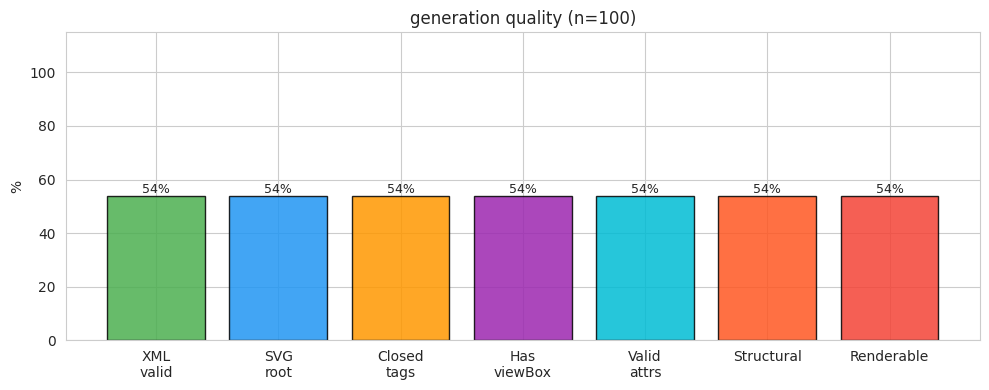

In [11]:
print("=== evaluation ===\n")
test_loss=eval_loss(model,test_ds,n_batches=500)
test_ppl=math.exp(min(test_loss,20))
print(f"test loss: {test_loss:.4f}\ntest perplexity: {test_ppl:.2f}")
print("\ngenerating 100 samples for stats...")
eval_samples=[]
for _ in tqdm(range(100)):
    t=random.choice([0.5,0.7,0.8,0.9,1.0])
    svg,tokens=generate(model,temp=t,top_k=50,top_p=0.9)
    info=check_svg(svg)
    info['temp']=t
    info['n_tok']=len(tokens)
    eval_samples.append(info)
n=len(eval_samples)
metrics={k:sum(1 for s in eval_samples if s.get(k))/n for k in ['valid_xml','has_svg_root','properly_closed','has_viewbox','valid_attrs','structural_valid','renderable']}
metrics['test_loss']=test_loss
metrics['test_ppl']=test_ppl
metrics['n_eval']=n
print(f"\nresults (n={n}):")
for k,v in metrics.items():
    if isinstance(v,float) and v<=1:print(f"  {k:<20}: {v*100:5.1f}%")
    else:print(f"  {k:<20}: {v}")
with open(f'{DRIVE}/results/eval_metrics.json','w') as f:json.dump(metrics,f,indent=2)

fig,ax=plt.subplots(figsize=(10,4))
labels=['XML\nvalid','SVG\nroot','Closed\ntags','Has\nviewBox','Valid\nattrs','Structural','Renderable']
keys=['valid_xml','has_svg_root','properly_closed','has_viewbox','valid_attrs','structural_valid','renderable']
values=[metrics[k]*100 for k in keys]
colors=['#4CAF50','#2196F3','#FF9800','#9C27B0','#00BCD4','#FF5722','#F44336']
bars=ax.bar(labels,values,color=colors,edgecolor='k',alpha=0.85)
for b,v in zip(bars,values):ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{v:.0f}%',ha='center',fontsize=9)
ax.set_ylabel('%')
ax.set_title(f'generation quality (n={n})')
ax.set_ylim(0,115)
plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/generation_quality.png',dpi=150)
plt.show()

## Done with Part 4Saved: `best_model.pt`, `extended_training.json`, `eval_metrics.json`, samples, plots